# preamble

## Auxilliary

In [1]:
import os
from pathlib import Path
from exp import runNSave, get_times_file, record_eye, record_fun3

/Users/wvw/git/n3/fun3/python/tests-bench/zika/exp.py:30: SyntaxWarning: invalid escape sequence '\d'
  netw_time = int(re.search("networking \d+ \[msec cputime\] (\d+) \[msec walltime\]", error).group(1))
/Users/wvw/git/n3/fun3/python/tests-bench/zika/exp.py:31: SyntaxWarning: invalid escape sequence '\d'
  reas_time = int(re.search("reasoning \d+ \[msec cputime\] (\d+) \[msec walltime\]", error).group(1))


## Config

In [2]:
path = "."

# rule files
rules_files = [ os.path.join(path, f"rules_red{nr}.n3") for nr in range(0, 2) ]
# datasets
data_files = [ os.path.join(path, "data", f"gen{size}_pt{pt}.n3") for size in [ 100, 200, 500, 700, 1000, 2000, 5000, 7000, 10000 ] for pt in [ 1, 2 ] ]
# data_files = [ os.path.join(path, "data", f"gen{size}_pt{pt}.n3") for size in [ 100 ] for pt in [ 1 ] ]

# number of experiment runs
nr_runs = 5

# eye

Run the performance experiments using the eye reasoner.

In [3]:
times_fh = get_times_file(os.path.join(path, "results"), 'eye')

query_file = os.path.join(path, "query_eye.n3")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)
    
        # dummy run (by analogy with fun3)
        runNSave(["eye", rules_file, data_files[0] , "--query", query_file, "--nope"], None)
    
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = Path(os.path.basename(rules_file)).stem
            data_name = Path(os.path.basename(data_file)).stem
            
            eye_res_file = os.path.join(path, "results", "out", f"eye-{rules_name}-{data_name}.n3")
            
            netw_time, reas_time = runNSave(["eye", rules_file, data_file , "--query", query_file, "--nope"], eye_res_file)
            # load TURTLE format
            # netw_time, reas_time = runNSave(["eye", rules_file, "--turtle", data_file , "--query", query_file, "--nope"], eye_res_file)
            record_eye(times_fh, run, rules_name, data_name, netw_time, reas_time)

            times_fh.flush()
    
times_fh.close()

run: 0
rules: ./rules_red0.n3
data: ./data/gen100_pt1.n3
data: ./data/gen100_pt2.n3
data: ./data/gen200_pt1.n3
data: ./data/gen200_pt2.n3
data: ./data/gen500_pt1.n3
data: ./data/gen500_pt2.n3
data: ./data/gen700_pt1.n3
data: ./data/gen700_pt2.n3
data: ./data/gen1000_pt1.n3
data: ./data/gen1000_pt2.n3
data: ./data/gen2000_pt1.n3
data: ./data/gen2000_pt2.n3
data: ./data/gen5000_pt1.n3
data: ./data/gen5000_pt2.n3
data: ./data/gen7000_pt1.n3
data: ./data/gen7000_pt2.n3
data: ./data/gen10000_pt1.n3
data: ./data/gen10000_pt2.n3
rules: ./rules_red1.n3
data: ./data/gen100_pt1.n3
data: ./data/gen100_pt2.n3
data: ./data/gen200_pt1.n3
data: ./data/gen200_pt2.n3
data: ./data/gen500_pt1.n3
data: ./data/gen500_pt2.n3
data: ./data/gen700_pt1.n3
data: ./data/gen700_pt2.n3
data: ./data/gen1000_pt1.n3
data: ./data/gen1000_pt2.n3
data: ./data/gen2000_pt1.n3
data: ./data/gen2000_pt2.n3
data: ./data/gen5000_pt1.n3
data: ./data/gen5000_pt2.n3
data: ./data/gen7000_pt1.n3
data: ./data/gen7000_pt2.n3
data: ./d

# fun3

Run the performance experiments using the fun3 reasoner.

In [9]:
from pathlib import Path
import sys
sys.path.insert(0, "../../")
from n3.to_py import run_py, save_py

In [ ]:
# generate code files (for testing memoization impact on # calls)

# for memoize in True, False:
#     code_file = os.path.join(path, "results", "code", f"code_out_{"mem" if memoize else "nonmem"}.py")
#     query_file = os.path.join(path, "query.n3")
#     rules_file = "rules_red1.n3"
#     data_file = os.path.join(path, "data", "gen5000_pt2.n3")

#     params = { 'code_dir': "../../..", 'tracing': 'count_calls', 'gen': { 'call_query': True, 'memoize': memoize } }
#     save_py(Path(query_file), Path(rules_file), Path(data_file), code_file, params=params)

In [10]:
memoize = False

times_fh = get_times_file(os.path.join(path, "results"), 'fun3')
query_file = os.path.join(path, "query.n3")

for run in range(0, nr_runs):
    print("run:", run)
    
    for rules_file in rules_files:
        print("rules:", rules_file)

        # dummy run
        # (unsure why but sometimes the first execution gives high execution times for no reason)
        run_py(Path(query_file), Path(rules_file), Path(data_files[0]), save_to=fun3_res_file, params=params)
        
        for data_file in data_files:
            print("data:", data_file)
            
            rules_name = Path(os.path.basename(rules_file)).stem
            data_name = Path(os.path.basename(data_file)).stem
            
            fun3_res_file = os.path.join(path, "results", "out", f"fun3-{rules_name}-{data_name}.n3")
            
            params = { 'gen': { 'memoize': memoize, 'experiment': True } }
            netw_time, save_time, gen_time, reas_time, total_time = run_py(Path(query_file), Path(rules_file), Path(data_file), save_to=fun3_res_file, params=params)
            record_fun3(times_fh, run, rules_name, data_name, netw_time, save_time, gen_time, reas_time, total_time)
    
            times_fh.flush()
    
times_fh.close()

run: 0
rules: ./rules_red0.n3
data: ./data/gen100_pt1.n3
data: ./data/gen100_pt2.n3
data: ./data/gen200_pt1.n3
data: ./data/gen200_pt2.n3
data: ./data/gen500_pt1.n3
data: ./data/gen500_pt2.n3
data: ./data/gen700_pt1.n3
data: ./data/gen700_pt2.n3
data: ./data/gen1000_pt1.n3
data: ./data/gen1000_pt2.n3
data: ./data/gen2000_pt1.n3
data: ./data/gen2000_pt2.n3
data: ./data/gen5000_pt1.n3
data: ./data/gen5000_pt2.n3
data: ./data/gen7000_pt1.n3
data: ./data/gen7000_pt2.n3
data: ./data/gen10000_pt1.n3
data: ./data/gen10000_pt2.n3
rules: ./rules_red1.n3
data: ./data/gen100_pt1.n3
data: ./data/gen100_pt2.n3
data: ./data/gen200_pt1.n3
data: ./data/gen200_pt2.n3
data: ./data/gen500_pt1.n3
data: ./data/gen500_pt2.n3
data: ./data/gen700_pt1.n3
data: ./data/gen700_pt2.n3
data: ./data/gen1000_pt1.n3
data: ./data/gen1000_pt2.n3
data: ./data/gen2000_pt1.n3
data: ./data/gen2000_pt2.n3
data: ./data/gen5000_pt1.n3
data: ./data/gen5000_pt2.n3
data: ./data/gen7000_pt1.n3
data: ./data/gen7000_pt2.n3
data: ./d

# compare output

Compare the outputs generated by eye and fun3.

In [48]:
import sys
sys.path.insert(0, "../../")

from n3.parse import parse_n3_file

for rules_file in rules_files:
    print("rules:", rules_file)

    for data_file in data_files:
        print("data:", data_file)
        
        rules_name = Path(os.path.basename(rules_file)).stem
        data_name = Path(os.path.basename(data_file)).stem
        
        eye_res_file = os.path.join(path, "results", "out", f"eye-{rules_name}-{data_name}.n3")
        fun3_res_file = os.path.join(path, "results", "out", f"fun3-{rules_name}-{data_name}.n3")

        model1 = parse_n3_file(eye_res_file).data; label1 = "eye"
        model2 = parse_n3_file(fun3_res_file).data; label2 = "fun3"

        compliant = True
        for t in model1.triples():
            if t not in model2.triples():
                print(f"different in {label1}:")
                print(t)
                compliant = False
                
        for t in model2.triples():
            if t not in model1.triples():
                print(f"different in {label2}:")
                print(t)
                compliant = False
                    
        if compliant:
            print("compliant")
        else:
            print("NON COMPLIANT")

rules: ./rules_red0.n3
data: ./data/gen100_pt1.n3
compliant
data: ./data/gen100_pt2.n3
compliant
data: ./data/gen200_pt1.n3
compliant
data: ./data/gen200_pt2.n3
compliant
data: ./data/gen500_pt1.n3
compliant
data: ./data/gen500_pt2.n3
compliant
data: ./data/gen700_pt1.n3
compliant
data: ./data/gen700_pt2.n3
compliant
data: ./data/gen1000_pt1.n3
compliant
data: ./data/gen1000_pt2.n3
compliant
data: ./data/gen2000_pt1.n3
compliant
data: ./data/gen2000_pt2.n3
compliant
data: ./data/gen5000_pt1.n3
compliant
data: ./data/gen5000_pt2.n3
compliant
data: ./data/gen7000_pt1.n3
compliant
data: ./data/gen7000_pt2.n3
compliant
data: ./data/gen10000_pt1.n3
compliant
data: ./data/gen10000_pt2.n3
compliant
rules: ./rules_red1.n3
data: ./data/gen100_pt1.n3
compliant
data: ./data/gen100_pt2.n3
compliant
data: ./data/gen200_pt1.n3
compliant
data: ./data/gen200_pt2.n3
compliant
data: ./data/gen500_pt1.n3
compliant
data: ./data/gen500_pt2.n3
compliant
data: ./data/gen700_pt1.n3
compliant
data: ./data/gen7

# analyze

Analyze the performance of eye and fun3.

In [4]:
from exp import load_n3_times, load_n3_agg

In [5]:
import matplotlib.pyplot as plt

def plot_query(df_eye, df_fun3, data_label, query_id=None, datasets=None, col='total_time', label=None):
    if label is None:
        label = f"dataset {data_label}"
        if query_id is not None:
            label = f"ruleset {query_id+1} ({label})"
        
    if datasets is not None:
        print(datasets)
        df_eye = df_eye[df_eye['data'].isin(datasets)]
        df_fun3 = df_fun3[df_fun3['data'].isin(datasets)]
        
    plot(label, df_eye, df_fun3, col)

def plot(name, df_eye, df_fun3, col):
    fig, ax = plt.subplots()
    ax.set_title(name)

    df_eye.plot(x='data_id', y=col, ax=ax, label='eye', xlabel="dataset (# patients)", ylabel=f"{col} (ms)")
    df_fun3.plot(x='data_id', y=col, ax=ax, label='fun3', xlabel="dataset (# patients)", ylabel=f"{col} (ms)")

In [6]:
def avg_times(sys,df):
    print(sys)
    print("avg load time:", round(df['netw_time'].mean(), 0))
    print("avg reasoning time:", round(df['reas_time'].mean(), 0))
    if sys == 'fun3':
        print("avg code gen time:", round(df['gen_time'].mean(), 0))
    print("avg total time:", round(df['total_time'].mean(), 0))

## overall

In [7]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), data_limit=5000)
# df_eye = load_n3_times(os.path.join(path, "results", "times_eye_turtle.csv"))
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), data_limit=5000)

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1405.0
avg reasoning time: 7.0
avg total time: 1411.0
fun3
avg load time: 292.0
avg reasoning time: 106.0
avg code gen time: 4.0
avg total time: 402.0


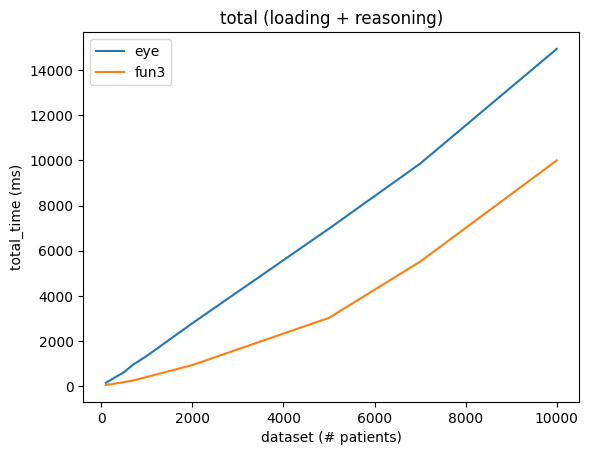

In [8]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1", data_limit=10000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1", data_limit=10000)
plot_query(df_eye, df_fun3, "2%", 1, col='total_time', label="total (loading + reasoning)")

## loading times

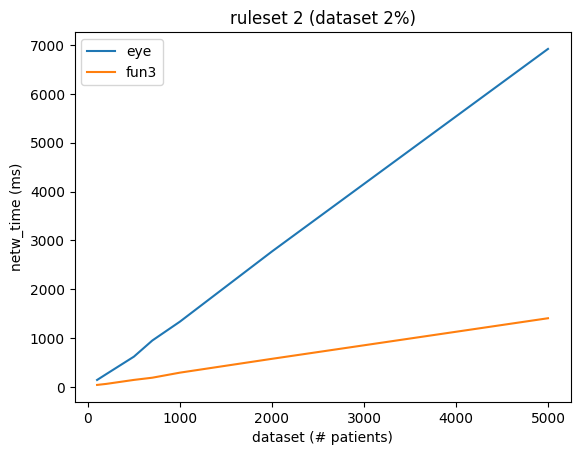

In [9]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1", data_limit=5000)
plot_query(df_eye, df_fun3, "2%", 1, col='netw_time')

## reasoning times

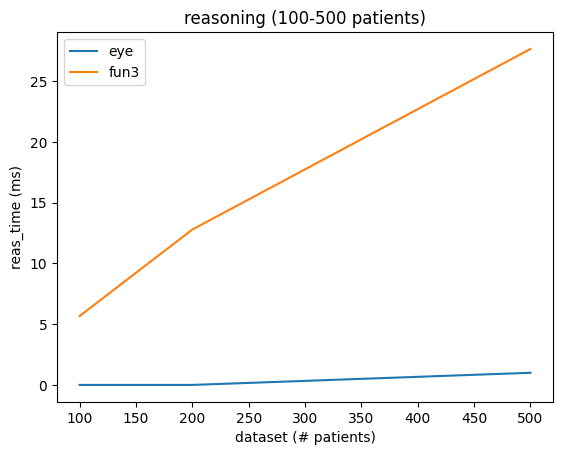

In [10]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1", data_limit=500)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1", data_limit=500)
plot_query(df_eye, df_fun3, "2%", 1, col='reas_time', label="reasoning (100-500 patients)")

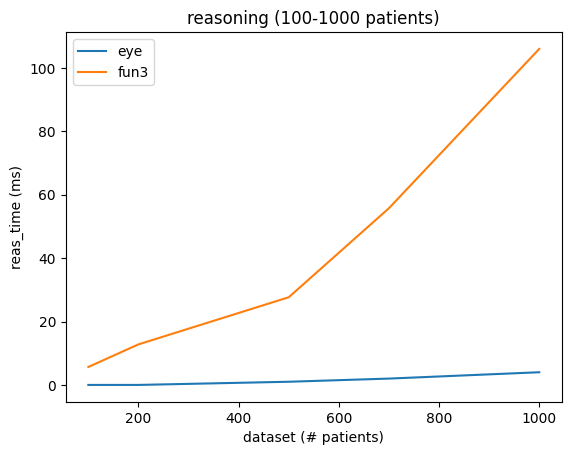

In [11]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1", data_limit=1000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1", data_limit=1000)
plot_query(df_eye, df_fun3, "2%", 1, col='reas_time', label="reasoning (100-1000 patients)")

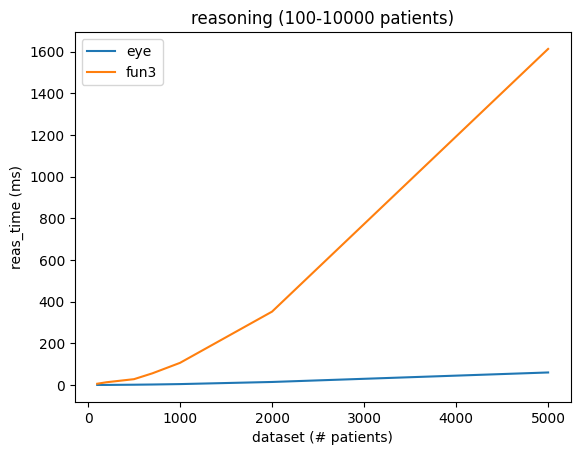

In [12]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1", data_limit=5000)
plot_query(df_eye, df_fun3, "2%", 1, col='reas_time', label="reasoning (100-10000 patients)")

In [13]:
df_fun3['nr'] = df_fun3['data_id'] / 100
df_fun3

,data,netw_time,reas_time,total_time,save_time,gen_time,data_id,nr
2,gen100_pt2,41.732333,5.667667,53.4,0.0,5.6,100,1.0
4,gen200_pt2,62.809233,12.790767,81.2,0.0,5.4,200,2.0
6,gen500_pt2,144.337925,27.662075,178.4,0.0,6.2,500,5.0
8,gen700_pt2,189.437867,55.762133,250.0,0.2,5.0,700,7.0
1,gen1000_pt2,292.973833,106.026167,404.2,0.0,5.0,1000,10.0
3,gen2000_pt2,575.962741,352.037259,933.6,0.0,5.2,2000,20.0
5,gen5000_pt2,1406.638908,1613.561092,3025.6,0.0,5.0,5000,50.0


In [14]:
import numpy as np
from scipy.optimize import curve_fit

def f(x, a, b, c):
    return a * np.pow(x, b) + c

popt, pcov = curve_fit(f, df_fun3['nr'], df_fun3['reas_time'])
popt

array([ 2.31523815,  1.67360117, -0.34300211])

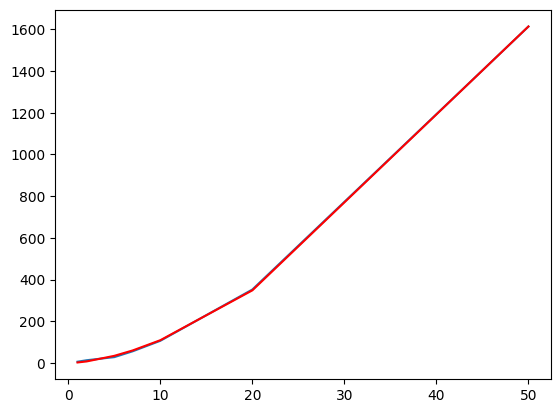

In [15]:
plt.plot(df_fun3['nr'], df_fun3['reas_time'])
plt.plot(df_fun3['nr'], f(df_fun3['nr'], *popt), 'r-', label="Fitted Curve")

## pt1

In [16]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), pt="pt1", data_limit=5000)
# df_eye = load_n3_times(os.path.join(path, "results", "times_eye_turtle.csv"), pt="pt1")
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", data_limit=5000)

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 956.0
avg reasoning time: 3.0
avg total time: 959.0
fun3
avg load time: 202.0
avg reasoning time: 37.0
avg code gen time: 4.0
avg total time: 242.0


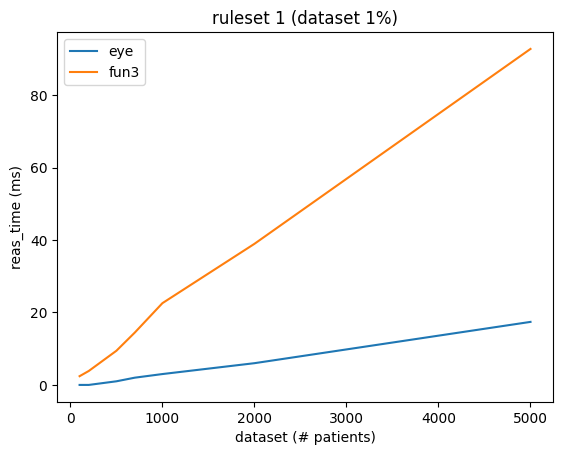

In [17]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="0", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="0", data_limit=5000)

plot_query(df_eye, df_fun3, "1%", 0, col="reas_time")

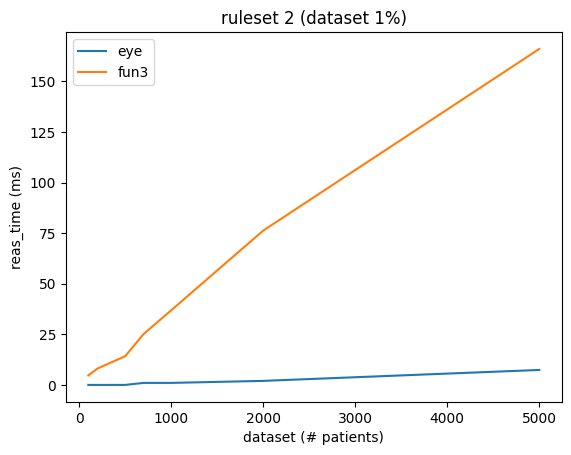

In [19]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt1", q="1", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt1", q="1", data_limit=5000)

plot_query(df_eye, df_fun3, "1%", 1, col='reas_time')

## pt2

In [21]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", data_limit=5000)

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1854.0
avg reasoning time: 10.0
avg total time: 1864.0
fun3
avg load time: 383.0
avg reasoning time: 175.0
avg code gen time: 4.0
avg total time: 563.0


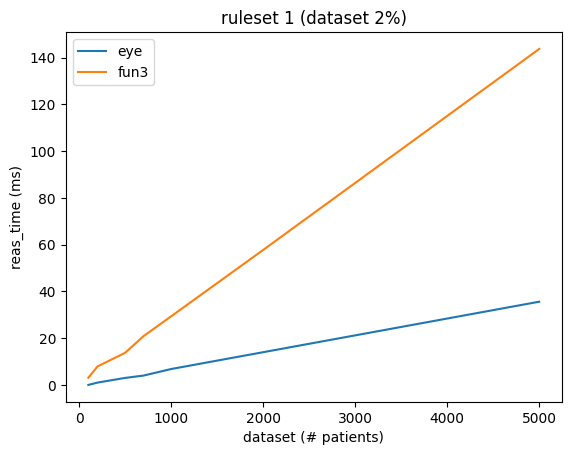

In [22]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="0", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="0", data_limit=5000)

plot_query(df_eye, df_fun3, "2%", 0, col='reas_time')

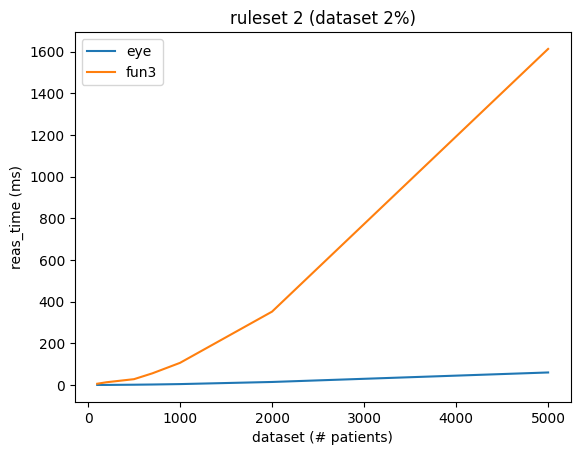

In [32]:
df_eye = load_n3_agg(os.path.join(path, "results", "times_eye.csv"), pt="pt2", q="1", data_limit=5000)
df_fun3 = load_n3_agg(os.path.join(path, "results", "times_fun3.csv"), pt="pt2", q="1", data_limit=5000)

plot_query(df_eye, df_fun3, "2%", 1, col='reas_time')

In [33]:
df_fun3

,data,netw_time,reas_time,total_time,save_time,gen_time,data_id
2,gen100_pt2,41.732333,5.667667,53.4,0.0,5.6,100
4,gen200_pt2,62.809233,12.790767,81.2,0.0,5.4,200
6,gen500_pt2,144.337925,27.662075,178.4,0.0,6.2,500
8,gen700_pt2,189.437867,55.762133,250.0,0.2,5.0,700
1,gen1000_pt2,292.973833,106.026167,404.2,0.0,5.0,1000
3,gen2000_pt2,575.962741,352.037259,933.6,0.0,5.2,2000
5,gen5000_pt2,1406.638908,1613.561092,3025.6,0.0,5.0,5000


In [34]:
df_eye

,data,netw_time,reas_time,total_time,data_id
2,gen100_pt2,143.4,0.0,143.4,100
4,gen200_pt2,263.4,0.0,263.4,200
6,gen500_pt2,620.4,1.0,621.4,500
8,gen700_pt2,950.6,2.0,952.6,700
1,gen1000_pt2,1336.8,4.0,1340.8,1000
3,gen2000_pt2,2773.0,14.2,2787.2,2000
5,gen5000_pt2,6919.4,59.8,6979.2,5000


## rule 0

In [28]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), q="0", data_limit=5000)
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), q="0", data_limit=5000)

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1402.0
avg reasoning time: 7.0
avg total time: 1408.0
fun3
avg load time: 287.0
avg reasoning time: 33.0
avg code gen time: 3.0
avg total time: 322.0


## rule 1

In [29]:
df_eye = load_n3_times(os.path.join(path, "results", "times_eye.csv"), q="1", data_limit=5000)
df_fun3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"), q="1", data_limit=5000)

avg_times('eye', df_eye)
avg_times('fun3', df_fun3)

eye
avg load time: 1408.0
avg reasoning time: 7.0
avg total time: 1415.0
fun3
avg load time: 298.0
avg reasoning time: 179.0
avg code gen time: 5.0
avg total time: 483.0


# sanity check

## consistency across runs

### eye

In [30]:
df_n3 = load_n3_times(os.path.join(path, "results", "times_eye.csv"))
cols = ['netw_time', 'reas_time', 'total_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# eye
# avg load time: 521.0
# avg reasoning time: 2.0
# avg total time: 523.0

,run,netw_time,reas_time,total_time
0,0,3145.666667,22.250000,3167.916667
1,1,3143.138889,22.083333,3165.222222
2,2,3147.055556,22.861111,3169.916667
3,3,3135.472222,22.027778,3157.500000
4,4,3142.000000,22.388889,3164.388889


### fun3

In [31]:
df_n3 = load_n3_times(os.path.join(path, "results", "times_fun3.csv"))
cols = ['netw_time', 'reas_time', 'total_time', 'gen_time']
df_n3_agg = df_n3.groupby(['run'])[cols].mean().reset_index()

df_n3_agg = df_n3_agg.sort_values(by='run')
df_n3_agg

# fun3
# avg load time: 23.0
# avg reasoning time: 952.0
# avg code gen time: 6.0
# avg total time: 975.0

,run,netw_time,reas_time,total_time,gen_time
0,0,700.892093,423.802352,1128.777778,3.833333
1,1,705.481907,422.406981,1131.694444,3.611111
2,2,701.147332,430.574890,1135.861111,3.972222
3,3,710.090753,422.520358,1136.416667,3.472222
4,4,675.453882,422.101674,1102.500000,4.694444
